In [7]:
# ===== 1. IMPORTS =====
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import sys

# Make the src/ package importable from within the notebooks/ subfolder.
sys.path.append("..")

# import constants and functions from our src/ modules to keep the notebook clean 
# and focused on the data.
from src.config import (
    SEED, TOP_K_FEATURES, POP_SIZE, N_GENERATIONS,
    MUTATION_RATE, CROSSOVER_RATE, TOURNAMENT_SIZE,
    EARLY_STOP_PATIENCE, MIN_IMPROVEMENT
)
from src.feature_prefilter import prefilter_features 
from src.ga_feature_selection import run_ga

In [8]:
# ===== 2. LOAD PRE-PROCESSED DATA =====
# use split and scaled data from 01_dataset_inspection.ipynb
with open("../data/processed/uci_full/uci_full_split_scaled.pkl", "rb") as f:
    X_train_scaled, X_test_scaled, y_train, y_test = pickle.load(f)

In [9]:
# ===== 3. PREFILTER FEATURES WITH MUTUAL INFORMATION =====
# quick prefiltering step to remove obviously irrelevant features and speed up the GA.
X_train_ga, X_test_ga, selected_prefilter_features, mi_series = prefilter_features(
    X_train_scaled,
    X_test_scaled,
    y_train,
    k=TOP_K_FEATURES,
    seed=SEED
)

print("Features before prefilter:", X_train_scaled.shape[1])
print("Features after prefilter:", X_train_ga.shape[1])

# Show the top-20 features
mi_series.head(20)

Features before prefilter: 111
Features after prefilter: 50


directory_length           0.379385
qty_slash_url              0.377510
qty_slash_directory        0.373561
qty_dot_directory          0.351079
file_length                0.349433
qty_dot_file               0.348828
qty_hyphen_directory       0.341939
qty_at_file                0.337386
qty_tilde_file             0.335613
qty_hashtag_directory      0.335399
qty_questionmark_file      0.335129
qty_equal_file             0.334994
qty_and_directory          0.334770
qty_hashtag_file           0.334373
qty_slash_file             0.334245
qty_underline_directory    0.334186
qty_equal_directory        0.334112
qty_dollar_directory       0.334038
qty_asterisk_file          0.333915
qty_hyphen_file            0.333793
dtype: float64

In [10]:
# ===== 4. RUN THE GENETIC ALGORITHM =====
# run
best_chromosome, best_fitness, selected_features, best_hist, avg_hist = run_ga(
    X_train_ga,
    y_train,
    pop_size=POP_SIZE,
    n_generations=N_GENERATIONS,
    mutation_rate=MUTATION_RATE,
    crossover_rate=CROSSOVER_RATE,
    tournament_size=TOURNAMENT_SIZE,
    early_stop_patience=EARLY_STOP_PATIENCE,
    min_improvement=MIN_IMPROVEMENT,
    seed=SEED
)

print("Best fitness:", best_fitness)
print("Selected feature count:", len(selected_features))
print(selected_features)

Generation   1 | Best: 0.9190 | Avg: 0.8891
Generation   2 | Best: 0.9194 | Avg: 0.9034
Generation   3 | Best: 0.9213 | Avg: 0.9113
Generation   4 | Best: 0.9213 | Avg: 0.9155
Generation   5 | Best: 0.9214 | Avg: 0.9182
Generation   6 | Best: 0.9214 | Avg: 0.9197
Generation   7 | Best: 0.9216 | Avg: 0.9202
Generation   8 | Best: 0.9216 | Avg: 0.9204
Early stopping triggered.
Best fitness: 0.9212595887320312
Selected feature count: 28
['directory_length', 'qty_slash_directory', 'qty_dot_directory', 'qty_dot_file', 'qty_hyphen_directory', 'qty_underline_directory', 'qty_equal_directory', 'qty_asterisk_file', 'qty_hyphen_file', 'qty_underline_file', 'qty_and_file', 'qty_space_file', 'qty_comma_file', 'qty_comma_directory', 'qty_exclamation_directory', 'qty_percent_directory', 'qty_exclamation_file', 'qty_at_directory', 'time_domain_activation', 'asn_ip', 'ttl_hostname', 'qty_dot_domain', 'qty_percent_params', 'params_length', 'qty_tilde_params', 'qty_equal_params', 'qty_dot_params', 'qty_

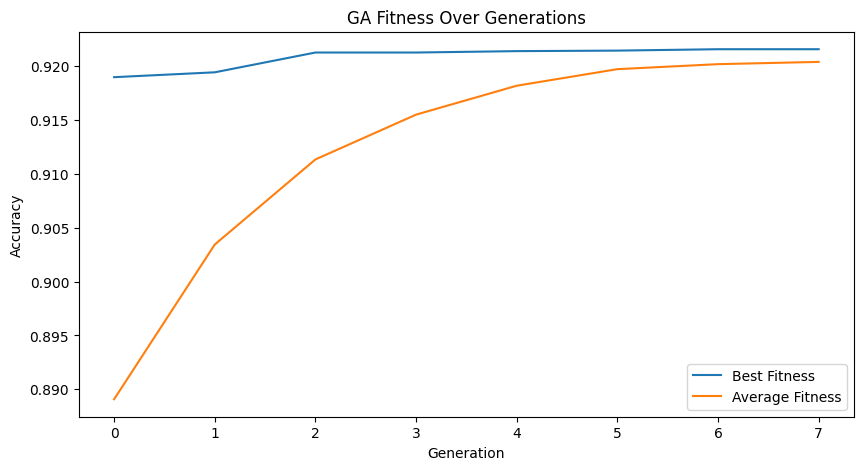

In [11]:
# ===== 5. PLOT GA CONVERGENCE =====
# plot the best and average fitness over generations to visualize convergence.
plt.figure(figsize=(10, 5))
plt.plot(best_hist, label="Best Fitness")
plt.plot(avg_hist, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.title("GA Fitness Over Generations")
plt.legend()
plt.show()

In [12]:
# ===== 6. SAVE GA RESULTS =====
# Save the selected features and GA history for later use in model evaluation and plotting.
#
# dataset1_selected_features.pkl  -> list of feature name strings chosen by the GA; 
# used to slice X_train/X_test when evaluating the final model.
#
# dataset1_ga_history.pkl  -> (best_hist, avg_hist) lists; used to reproduce the 
# convergence plot later.
with open("../data/processed/uci_full/uci_full_selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

with open("../data/processed/uci_full/uci_full_ga_history.pkl", "wb") as f:
    pickle.dump((best_hist, avg_hist), f)